1-Import libraries + data

In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/omarnasr9975/nyc-uber-fare-dataset/final_internship_data.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
data = pd.read_csv(
    '/kaggle/input/datasets/omarnasr9975/nyc-uber-fare-dataset/final_internship_data.csv'
)

print(data.shape)

(500000, 26)


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   User ID            500000 non-null  object 
 1   User Name          500000 non-null  object 
 2   Driver Name        500000 non-null  object 
 3   Car Condition      500000 non-null  object 
 4   Weather            500000 non-null  object 
 5   Traffic Condition  500000 non-null  object 
 6   key                500000 non-null  object 
 7   fare_amount        500000 non-null  float64
 8   pickup_datetime    500000 non-null  object 
 9   pickup_longitude   500000 non-null  float64
 10  pickup_latitude    500000 non-null  float64
 11  dropoff_longitude  499995 non-null  float64
 12  dropoff_latitude   499995 non-null  float64
 13  passenger_count    500000 non-null  int64  
 14  hour               500000 non-null  int64  
 15  day                500000 non-null  int64  
 16  mo

In [5]:
data.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
count,500000.000000,500000.000000,500000.000000,499995.000000,499995.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000
mean,11.358361,-1.265712,0.696740,-1.265755,0.696675,1.683428,13.510834,15.684206,6.268650,3.042008,2011.739132,385.279367,380.503657,363.843772,363.674038,355.991423,19.468775,0.297145
std,9.916617,0.206941,0.140909,0.205903,0.128997,1.307395,6.511571,8.681066,3.437815,1.949240,1.860889,2419.087483,2428.804740,2425.075903,2428.348683,2428.730839,367.299601,1.804548
min,-44.900000,-52.119764,-54.389440,-59.049665,-44.676047,0.000000,0.000000,1.000000,1.000000,0.000000,2009.000000,1.017646,1.460945,0.382119,0.532545,0.080500,0.000000,-3.141593
25%,6.000000,-1.291405,0.710958,-1.291393,0.710943,1.000000,9.000000,8.000000,3.000000,1.000000,2010.000000,41.341514,32.173712,17.100762,14.886989,7.147384,1.214550,-0.854721
50%,8.500000,-1.291226,0.711268,-1.291197,0.711277,1.000000,14.000000,16.000000,6.000000,3.000000,2012.000000,42.523163,34.787507,19.591554,18.347580,10.458151,2.116970,-0.050442
75%,12.500000,-1.290970,0.711520,-1.290908,0.711538,2.000000,19.000000,23.000000,9.000000,5.000000,2013.000000,43.785649,38.304502,22.214815,22.417812,14.448699,3.890070,2.206769
max,500.000000,37.360538,29.724576,0.712985,7.061893,6.000000,23.000000,31.000000,12.000000,6.000000,2015.000000,30133.067880,30167.595967,30167.285794,30159.407296,30162.285356,12399.956433,3.141593


2-Data Cleaning

In [6]:
"""A-Check Duplicates and remove if found"""

print("Duplicate keys:", data['key'].duplicated().sum())
data = data.drop_duplicates(subset='key')

Duplicate keys: 0


In [7]:
"""B-Remove Costing Features"""
data = data.drop(columns=['User ID', 'User Name', 'Driver Name', 'key'])

In [8]:
"""C-Handling null values"""

data=data.dropna()
data.shape

(499995, 22)

In [9]:
"""D-Handling inappropriate values in some columns"""

cols = [
    'pickup_longitude',
    'pickup_latitude',
    'dropoff_longitude',
    'dropoff_latitude',
    'distance',
    'bearing'
]

data = data[(data[cols] != 0).all(axis=1)]
data.shape

(484787, 22)

In [10]:
#Rounding up some values
cols1 = [
    'distance',
    'jfk_dist',
    'ewr_dist',
    'lga_dist',
    'sol_dist',
    'nyc_dist'
]

data[cols1] = data[cols1].round(2)

In [11]:
#Check all fare amounts are positive
data = data[data['fare_amount'] > 0]
data.shape

(484757, 22)

In [12]:
#Check no of customers not to equal zero
data = data[data['passenger_count'] > 0]
data.shape

(483011, 22)

In [13]:
#Check distance is a positive number
data = data[data['distance'] > 0]
data.shape

(482121, 22)

In [14]:
#Ensure pickup_datetime is a DateTime object not just normal string
data['pickup_datetime'] = pd.to_datetime(data['pickup_datetime'])
print(data['pickup_datetime'].dtype)

datetime64[ns]


In [15]:
#Change values of these columns for better visualization
coord_cols = ['pickup_longitude', 'pickup_latitude',
              'dropoff_longitude', 'dropoff_latitude']

data[coord_cols] = data[coord_cols].apply(np.degrees)

print(data[coord_cols].describe())

       pickup_longitude  pickup_latitude  dropoff_longitude  dropoff_latitude
count     482121.000000    482121.000000      482121.000000     482121.000000
mean         -73.914547        40.691832         -73.920553         40.682862
std            6.310080         3.897081           6.254354          4.985506
min        -2986.242495      -880.627428       -3383.296608      -2559.748913
25%          -73.992268        40.736549         -73.991564         40.735600
50%          -73.982098        40.753383         -73.980602         40.753887
75%          -73.968466        40.767482         -73.965408         40.768420
max         2140.601160      1703.092772          40.851027        404.616667


In [16]:
#Change bearings from radians to degrees and ensuring values are between 0 to 360
data['bearing'] = np.degrees(data['bearing'])
data['bearing'] = (data['bearing'] + 360) % 360
print(data['bearing'].min(), data['bearing'].max())

0.0022550697361225502 359.9999906984909


In [17]:
#Since the Dataset is on trips happened in New York City
"""Check that boundaries of all trips are actually in New York City Boundaries (Not an Outlier)"""
# Approximate geographic boundaries of New York City (retrieved from google)
# Longitude: -74.3 to -72.9
# Latitude: 40.5 to 41.8
nyc_bounds = {
    'lon_min': -74.3, 'lon_max': -72.9,
    'lat_min': 40.5, 'lat_max': 41.8
}

valid_mask = (
    data['pickup_longitude'].between(nyc_bounds['lon_min'], nyc_bounds['lon_max']) &
    data['pickup_latitude'].between(nyc_bounds['lat_min'], nyc_bounds['lat_max']) &
    data['dropoff_longitude'].between(nyc_bounds['lon_min'], nyc_bounds['lon_max']) &
    data['dropoff_latitude'].between(nyc_bounds['lat_min'], nyc_bounds['lat_max'])
)

print("Rows outside NYC bounds:", len(data) - valid_mask.sum())
data = data[valid_mask]
data.shape

Rows outside NYC bounds: 606


(481515, 22)

In [18]:
#Rounding them up to 4 decimals
coord_cols1 = ['pickup_longitude', 'pickup_latitude',
              'dropoff_longitude', 'dropoff_latitude']

data[coord_cols1] = data[coord_cols1].round(4)

# Rounding bearing to 2 decimals
data['bearing'] = data['bearing'].round(2)

In [19]:
#Renaming Day and adding day of the week
data = data.rename(columns={'day': 'day_of_month'})

In [20]:
#refining the names of the columns
data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_')

In [21]:
#remove very short rides with high fare amount (outliers)
data = data[~((data['distance'] < 1) & (data['fare_amount'] > 100))]
data = data[~((data['distance'] < 5) & (data['fare_amount'] > 150))]
print("New shape:", data.shape)

New shape: (481498, 22)


In [22]:
#remove very long trips with very low fare amounts (outliers)
data = data[~((data['distance'] > 50) & (data['fare_amount'] < 20))]
data.shape

(481434, 22)

In [23]:
# I checked the trips with very large distances.

# Found 5 trips with the exact same pickup location.
# They happened on different dates but all started from the same coordinates,
# which suggests these coordinates are incorrect (likely a default or stuck GPS location).
# Their fares ($35-$50) are also too low for trips over 100 km, so we remove them.

data = data[~((data['pickup_longitude'] == -73.1374) & (data['pickup_latitude'] == 41.3661))]

# Investigated rows with distance > 7.98km (upper IQR bound) and fare < $5:
# found 149 rides with 8-22km distance but $2.50-$4.90 fare
# These fare-distance combinations are unrealistic and match the same data quality issue
# identified during the initial cleaning.
# Remove these inconsistent records.
data = data[~((data['distance'] > 7.98) & (data['fare_amount'] < 5))]

print(data.shape)

(481273, 22)


**Note on leakage scope:** the row-filtering steps above (nulls, invalid values, outlier
removal) were computed on the full dataset before the split. This is a common, accepted
practice for coursework since these are domain-driven filters (impossible values, physically
implausible fare/distance combos), not statistical fits — but strictly speaking the IQR bound
used in outlier detection was derived from the full dataset. A fully rigorous version would
re-derive that bound from `X_train` only. Flagged here as a known limitation.

3- Train/Test Split

In [24]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=['fare_amount'])
y = data['fare_amount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(385018, 21) (96255, 21)


In [25]:
# pickup_datetime already used to extract hour, day_of_month, month, weekday
# The raw datetime column itself isn't usable by sklearn models, so we drop it now that
# all relevant components have been extracted.
X_train = X_train.drop(columns=['pickup_datetime'])
X_test = X_test.drop(columns=['pickup_datetime'])

4- Feature Engineering (computed on X_train only, applied identically to X_test)

In [26]:
"""A - Airport trip flag"""

# Task 1 EDA finding: raw airport-distance correlation with fare was misleading
# (JFK correlation with fare was -0.47, dominated by 481K unrelated city trips).
# Isolating true airport-area trips (<2km from pickup) revealed a real fare premium:
# JFK avg $14.61 vs $11.31 overall, LGA avg $8.79 (closer to Manhattan, shorter trips).
# This is a fixed, deterministic threshold (not fit from data), so applying it
# separately to X_train and X_test carries no leakage risk.

AIRPORT_RADIUS_KM = 2

for df_ in [X_train, X_test]:
    df_['is_airport_trip'] = (
        (df_['jfk_dist'] < AIRPORT_RADIUS_KM) |
        (df_['ewr_dist'] < AIRPORT_RADIUS_KM) |
        (df_['lga_dist'] < AIRPORT_RADIUS_KM)
    ).astype(int)

print(X_train['is_airport_trip'].value_counts())

is_airport_trip
0    384831
1       187
Name: count, dtype: int64


In [27]:
"""B - Check distance-related features for redundancy (X_train only)"""

distance_features = ['jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist', 'nyc_dist', 'distance']
corr_matrix = X_train[distance_features].corr()
corr_matrix

,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance
jfk_dist,1.000000,-0.420533,-0.110757,-0.197630,-0.244009,-0.502398
ewr_dist,-0.420533,1.000000,-0.512556,0.957094,0.944874,0.457905
lga_dist,-0.110757,-0.512556,1.000000,-0.547801,-0.444179,0.126318
sol_dist,-0.197630,0.957094,-0.547801,1.000000,0.984523,0.385487
nyc_dist,-0.244009,0.944874,-0.444179,0.984523,1.000000,0.452226
distance,-0.502398,0.457905,0.126318,0.385487,0.452226,1.000000


In [28]:
"""C - Drop redundant distance features"""

# sol_dist, ewr_dist, and nyc_dist are highly inter-correlated (r > 0.94 pairwise)
# near-duplicate geographic info, since EWR, Statue of Liberty, and "NYC center" are
# all clustered near lower Manhattan/NY Harbor. Keeping ewr_dist (strongest correlation
# with distance, our top fare predictor).
#jfk_dist/lga_dist correlate weakly (|r|<0.55) with the rest,
#so both are kept (distinct geographic information.)

X_train = X_train.drop(columns=['sol_dist', 'nyc_dist'])
X_test = X_test.drop(columns=['sol_dist', 'nyc_dist'])
print(X_train.shape, X_test.shape)

(385018, 19) (96255, 19)


5- Feature Selection (X_train only)

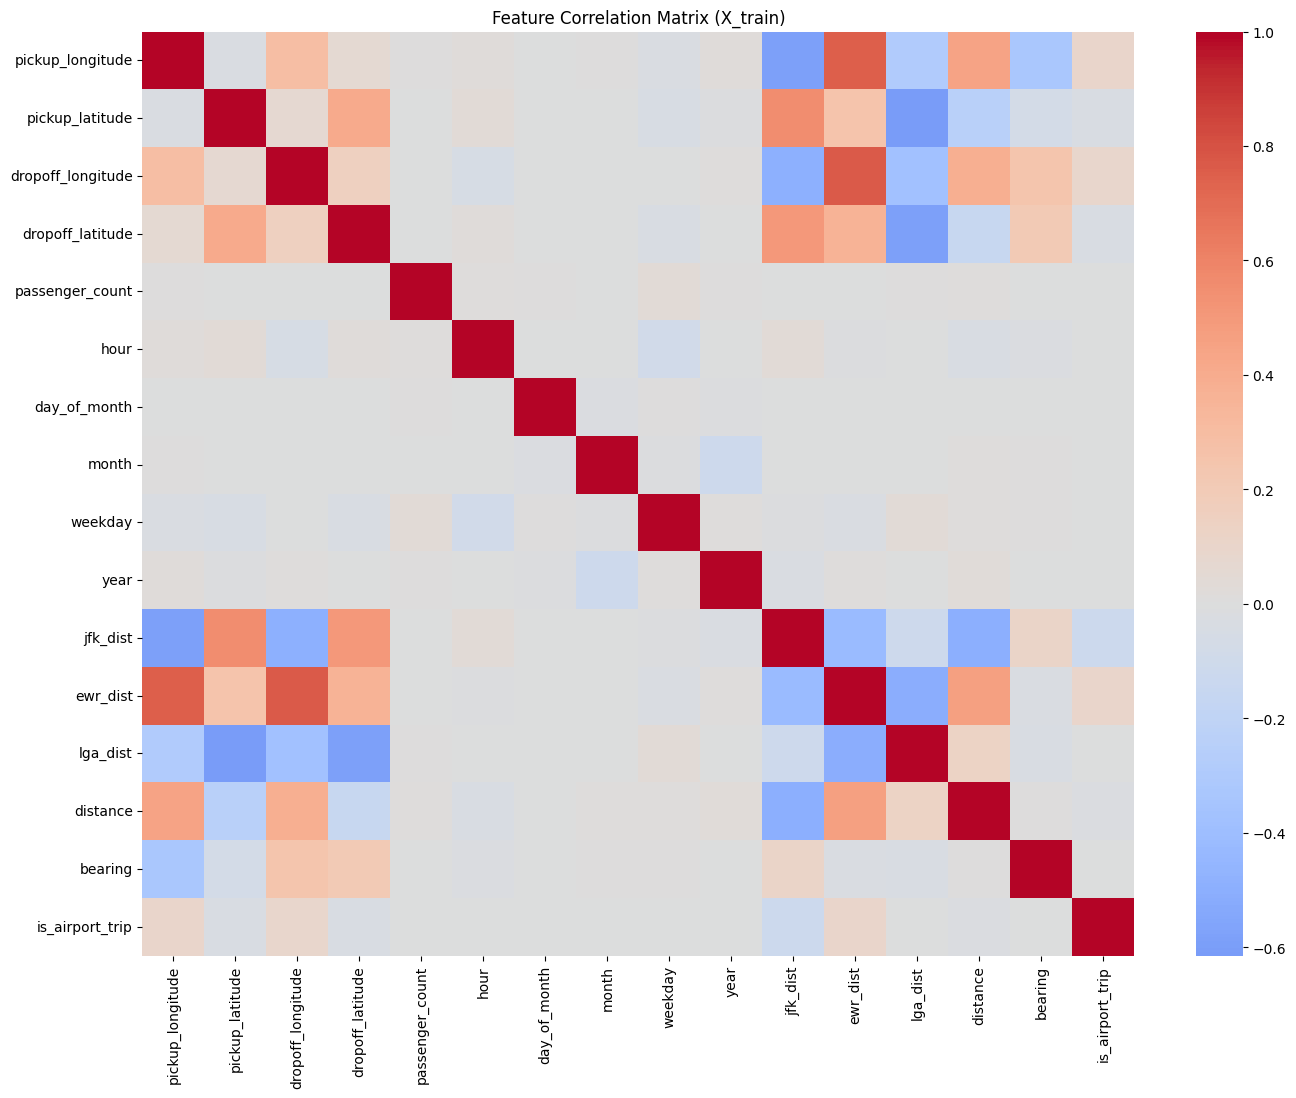

In [29]:
"""A - Correlation among features (multicollinearity check)"""

plt.figure(figsize=(16, 12))
sns.heatmap(X_train.corr(numeric_only=True), cmap='coolwarm', center=0, annot=False)
plt.title('Feature Correlation Matrix (X_train)')
plt.show()

**Insight:** Pickup/dropoff coordinates and the landmark distances (jfk_dist, ewr_dist,
lga_dist) form one strongly correlated cluster -- expected, since the distances are
calculated directly from those same coordinates. All other features (weather, traffic,
time-based, car condition) show no meaningful correlation with anything.

In [30]:
"""B - VIF (Variance Inflation Factor) quantify multicollinearity severity"""

# Rule of thumb: VIF > 10 = severe multicollinearity.

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

vif_features = [
    'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
    'jfk_dist', 'ewr_dist', 'lga_dist', 'distance', 'year', 'passenger_count'
]

X_vif = add_constant(X_train[vif_features])
vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif_data = vif_data[vif_data['feature'] != 'const']
print(vif_data.sort_values('VIF', ascending=False))

              feature        VIF
6            ewr_dist  66.587433
1    pickup_longitude  30.512247
3   dropoff_longitude  28.377423
5            jfk_dist  20.777254
4    dropoff_latitude  10.922843
2     pickup_latitude  10.673153
7            lga_dist   6.043695
8            distance   1.765235
9                year   1.000775
10    passenger_count   1.000271


In [31]:
"""C - Drop raw coordinates (root cause of severe multicollinearity)"""

# VIF showed severe multicollinearity among pickup/dropoff coordinates
# and the landmark distances derived from them. Dropping raw coordinates; the
# distances are more directly interpretable for fare prediction anyway.
# Decision made using X_train only; same drop applied to X_test.

coords_to_drop = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']
X_train = X_train.drop(columns=coords_to_drop)
X_test = X_test.drop(columns=coords_to_drop)
print(X_train.shape, X_test.shape)

(385018, 15) (96255, 15)


In [32]:
"""D - Confirm VIF fix """

vif_features = ['jfk_dist', 'ewr_dist', 'lga_dist', 'distance', 'year', 'passenger_count']
X_vif = add_constant(X_train[vif_features])
vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif_data = vif_data[vif_data['feature'] != 'const']
print(vif_data.sort_values('VIF', ascending=False))

           feature       VIF
2         ewr_dist  2.525357
3         lga_dist  1.909568
4         distance  1.723523
1         jfk_dist  1.557786
5             year  1.000718
6  passenger_count  1.000260


6- Full Preprocessing Pipeline (Encoding + Scaling + Cyclical Encoding)

In [33]:
%pip install feature_engine

Note: you may need to restart the kernel to use updated packages.


In [34]:
"""Preprocessing pipeline:
- Encode categorical features
- Scale numerical features
- Transform cyclical features

All preprocessing is performed inside the pipeline to prevent data leakage.
"""

from sklearn.compose import ColumnTransformer # Apply different preprocessing to different column groups
from sklearn.pipeline import Pipeline #To execute multiple steps in a fixed order as one object + prevents leakage by fitting preprocessing steps only on the training
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from feature_engine.creation import CyclicalFeatures

# Ordinal: car_condition has a genuine order
ordinal_features = ['car_condition']
condition_order = [['Bad', 'Good', 'Very Good', 'Excellent']]

# Nominal: weather, traffic_condition (no natural order)
nominal_features = ['weather', 'traffic_condition']

# Continuous: scaled with StandardScaler
numeric_features = ['distance', 'jfk_dist', 'ewr_dist', 'lga_dist', 'year']

# Cyclical: sin/cos encoded
cyclical_features = ['bearing', 'hour', 'month', 'weekday', 'day_of_month']
cyclical_max_values = {'bearing': 360, 'hour': 24, 'month': 12, 'weekday': 7, 'day_of_month': 31}

# passenger_count, is_airport_trip pass through untouched (already numeric with limited range)

cyclical_pipeline = Pipeline([
    ('cyclical', CyclicalFeatures(variables=cyclical_features, max_values=cyclical_max_values, drop_original=True))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(categories=condition_order), ordinal_features),
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), nominal_features),
        ('scale', StandardScaler(), numeric_features),
        ('cyclical', cyclical_pipeline, cyclical_features)
    ],
    remainder='passthrough'
)

7- Cross-Validation + Baseline Model (Linear Regression)

In [35]:
"""Baseline pipeline: full preprocessing + Linear Regression

building and evaluating a baseline Linear Regression model using cross-validation.
Before trying advanced models or feature improvements to measure its expected performance.
"""


from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score

baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# 5-Fold CV , standard choice for i.i.d tabular regression data /use data efficiently / give reliable score /detect overfitting
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    baseline_pipeline, X_train, y_train,
    cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1
)

print("CV RMSE scores:", -cv_scores)
print("Mean CV RMSE:", -cv_scores.mean())
print("Std CV RMSE:", cv_scores.std())

CV RMSE scores: [4.13465262 4.01581337 4.00355359 4.00634358 4.04626931]
Mean CV RMSE: 4.041326493152721
Std CV RMSE: 0.04906264184372812


In [36]:
"""trains baseline Linear Regression model on the training data and evaluates it on unseen test data."""

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

baseline_pipeline.fit(X_train, y_train)
y_pred_baseline = baseline_pipeline.predict(X_test)

baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
baseline_r2 = r2_score(y_test, y_pred_baseline)

print(f"Baseline Linear Regression -- MAE: {baseline_mae:.3f}, RMSE: {baseline_rmse:.3f}, R2: {baseline_r2:.3f}")

Baseline Linear Regression -- MAE: 2.152, RMSE: 4.037, R2: 0.820


Baseline Model Results:

Mean CV RMSE = 4.041 → The model's average prediction error is about $4.04.

CV RMSE Std = 0.049 → Very small variation between folds, meaning the model is
stable.

Test RMSE = 4.037 → Test performance is consistent with cross-validation
results, indicating no clear overfitting.

MAE = 2.152 → Predictions are off by about $2.15 on average.

R² = 0.820 → The model explains 82% of the variation in taxi fare prices.

Conclusion:
The baseline Linear Regression model provides a strong and stable starting point.

Future models or feature engineering should aim to achieve RMSE lower than 4.04
and improve the R² score above 0.82.

8- Hyperparameter Tuning (Random Forest Regressor)

In [37]:
"""Tuned model: Random Forest, tuned via RandomizedSearchCV.
Chosen over a second Linear Regression variant since it can capture non-linear
interactions that Linear Regression cannot."""

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_jobs= 1))
])

param_distributions = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__max_features': ['sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_distributions,
    n_iter=15,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best CV RMSE:", -random_search.best_score_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__max_features': 'log2', 'model__max_depth': 30}
Best CV RMSE: 3.35458539952876


In [38]:
"""Evaluate tuned model on held-out test set"""

best_rf_pipeline = random_search.best_estimator_
y_pred_tuned = best_rf_pipeline.predict(X_test)

tuned_mae = mean_absolute_error(y_test, y_pred_tuned)
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
tuned_r2 = r2_score(y_test, y_pred_tuned)

print(f"Tuned Random Forest -- MAE: {tuned_mae:.3f}, RMSE: {tuned_rmse:.3f}, R2: {tuned_r2:.3f}")

Tuned Random Forest -- MAE: 1.677, RMSE: 3.348, R2: 0.876


9- Results Table

In [39]:
results = pd.DataFrame({
    'Model': ['Baseline (Linear Regression)', 'Tuned (Random Forest)'],
    'MAE': [baseline_mae, tuned_mae],
    'RMSE': [baseline_rmse, tuned_rmse],
    'R2': [baseline_r2, tuned_r2]
})

results

,Model,MAE,RMSE,R2
0,Baseline (Linear Regression),2.151853,4.037306,0.820000
1,Tuned (Random Forest),1.677047,3.347682,0.876241


**What I would try next:**
- Try Gradient Boosting (XGBoost/LightGBM) instead of Random Forest — usually performs better on this kind of tabular data.

- Apply a log transform to `fare_amount` before training, since fares are right-skewed, then convert predictions back before calculating MAE/RMSE.

- Re-check outlier removal using only training data, to fully avoid any leakage from the test set.

- Try automatic feature selection (e.g. Lasso) instead of the manual VIF-based approach
  used here.

10- Save Fitted Pipeline

In [40]:
import joblib

joblib.dump(best_rf_pipeline, 'uber_fare_pipeline.pkl')
print("Pipeline saved as uber_fare_pipeline.pkl")

Pipeline saved as uber_fare_pipeline.pkl
